In [1]:
import numpy as np
# Define the coefficient matrix A and the right-hand side vector B
A = np.array([[2, 1], [1, 3]])
B = np.array([4, 7])
# Solve for the variables X using matrix inversion
X = np.linalg.inv(A).dot(B)
print("Solution:")
print(X)


Solution:
[1. 2.]


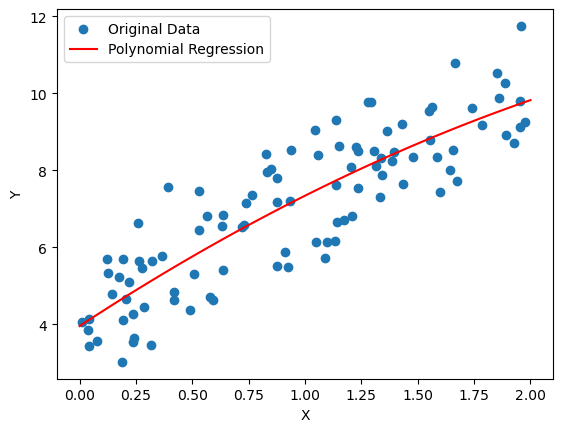

Coefficients:
[[ 0.          3.84100842 -0.45190593]]
Intercept:
[3.95139826]


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
# Generate sample data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
Y = 4 + 3 * X + np.random.randn(100, 1)
# Fit a polynomial regression model
degree = 2 # You can change the degree as needed
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, Y)
# Make predictions
X_new = np.linspace(0, 2, 100).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)
Y_new = model.predict(X_new_poly)
# Plot the original data and the polynomial regression curve
plt.scatter(X, Y, label='Original Data')
plt.plot(X_new, Y_new, 'r-', label='Polynomial Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()
# The coefficients of the multivariate polynomial regression model
coefficients = model.coef_
intercept = model.intercept_
print("Coefficients:")
print(coefficients)
print("Intercept:")
print(intercept)

In [ ]:
import pandas as pd
df = pd.read_csv("Yield.csv")
# working for linear regression using calculus and same for
# polynomial regression.

X = df["Temp (X)"]
y = df["Yield (Y)"]

n = len(X)
sum_x = np.sum(X)
sum_x2 = np.sum(X*X)
sum_x3 = np.sum(X*X*X)
sum_x4 = np.sum(X*X*X*X)
sum_y = np.sum(y)
sum_xy = np.sum(X*y)
sum_x2y = np.sum(X*X*y)

Mat_A_lin = np.array([
    [n, sum_x],
    [sum_x, sum_x2]
])

Mat_B_lin = np.array([
    [sum_y],
    [sum_xy]
])


Mat_A_poly = np.array([
    [n, sum_x, sum_x2],
    [sum_x, sum_x2, sum_x3],
    [sum_x2, sum_x3, sum_x4]
])

Mat_B_poly = np.array([
    [sum_y],
    [sum_xy],
    [sum_x2y]
])

soln_lin = np.linalg.solve(Mat_A_lin, Mat_B_lin)
soln_poly = np.linalg.solve(Mat_A_poly,Mat_B_poly)

In [15]:
soln_poly

array([[ 7.96048110e+00],
       [-1.53711340e-01],
       [ 1.07560137e-03]])

In [16]:
soln_lin

array([[2.30630631],
       [0.00675676]])

LINEAR - MSE: 0.132709  RMSE: 0.364292
POLY - MSE: 0.047785  RMSE: 0.218597


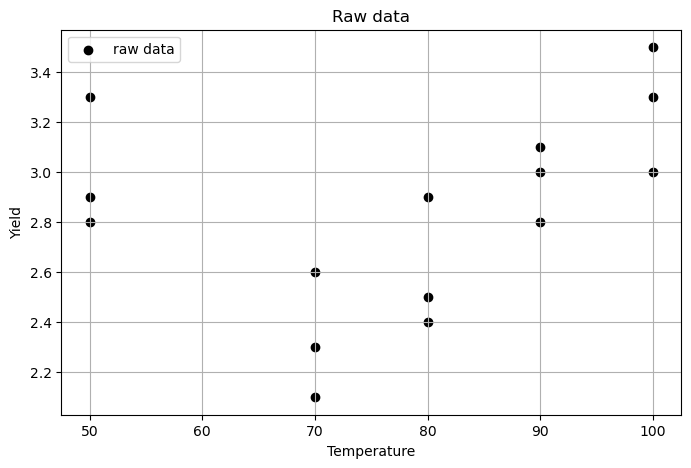

In [20]:
y_pred_lin = soln_lin[0] + soln_lin[1] * X
y_pred_poly = soln_poly[0] + soln_poly[1] * X + soln_poly[2] * X**2

err_lin  = y - y_pred_lin
err_poly = y - y_pred_poly

mse_lin  = np.mean(err_lin**2)
mse_poly = np.mean(err_poly**2)

rmse_lin  = np.sqrt(mse_lin)
rmse_poly = np.sqrt(mse_poly)

print("LINEAR - MSE:", round(mse_lin,6), " RMSE:", round(rmse_lin,6))
print("POLY - MSE:", round(mse_poly,6), " RMSE:", round(rmse_poly,6))

plt.figure(figsize=(8,5))
plt.scatter(X, y, color="black", label="raw data")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.title("Raw data")
plt.legend()
plt.grid(True)
plt.show()

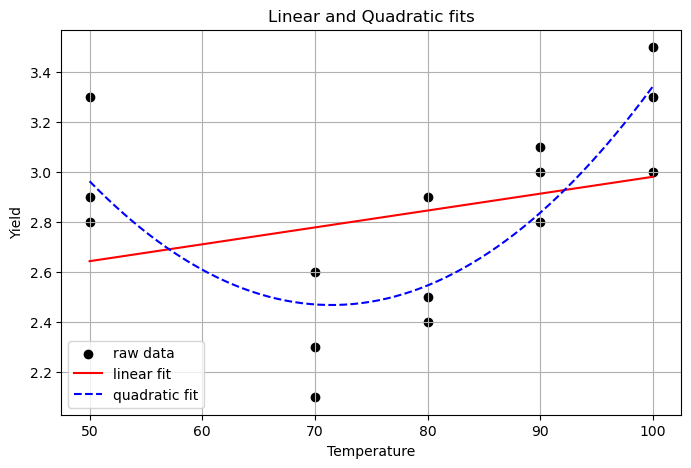

In [21]:
x_line = np.linspace(X.min(), X.max(), 200)
y_line_lin  = soln_lin[0] + soln_lin[1] * x_line
y_line_poly = soln_poly[0] + soln_poly[1] * x_line + soln_poly[2] * x_line**2

plt.figure(figsize=(8,5))
plt.scatter(X, y, color="black", label="raw data")
plt.plot(x_line, y_line_lin,  "r-",  label="linear fit")
plt.plot(x_line, y_line_poly, "b--", label="quadratic fit")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.title("Linear and Quadratic fits")
plt.legend()
plt.grid(True)
plt.show()

Fitted equation (matrix method):
Y = -0.1345 + 0.6127*Area + -0.2435*X2 + -0.0657*X3

MSE : 0.017028
RMSE: 0.130493

Coefficients:
Intercept (b0): -0.134536
Area      (b1): 0.612655
Early     (b2): -0.243482
Late      (b3): -0.065656


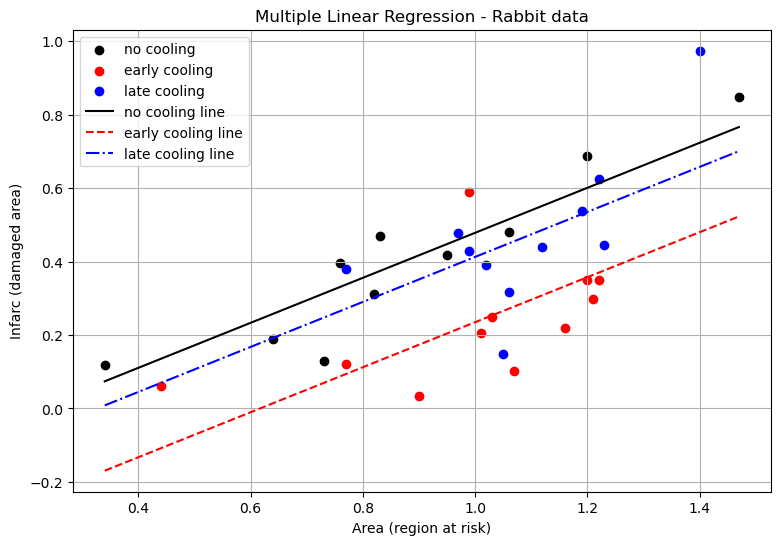

In [27]:
df = pd.read_csv("Rabbit.csv")
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

y  = df["Infarc"].values.astype(float)
x1 = df["Area"].values.astype(float)
x2 = df["X2"].values.astype(float)
x3 = df["X3"].values.astype(float)
n  = len(y)

ones = np.ones(n)
Xmat = np.column_stack((ones, x1, x2, x3))

beta = np.linalg.inv(Xmat.T @ Xmat) @ (Xmat.T @ y)
b0, b1, b2, b3 = beta

print("Fitted equation (matrix method):")
print(f"Y = {b0:.4f} + {b1:.4f}*Area + {b2:.4f}*X2 + {b3:.4f}*X3")
print()

y_pred = Xmat @ beta
err = y - y_pred
mse  = np.mean(err**2)
rmse = np.sqrt(mse)

print("MSE :", round(mse,6))
print("RMSE:", round(rmse,6))
print()

print("Coefficients:")
print("Intercept (b0):", round(b0,6))
print("Area      (b1):", round(b1,6))
print("Early     (b2):", round(b2,6))
print("Late      (b3):", round(b3,6))

plt.figure(figsize=(9,6))
mask0 = (x2==0) & (x3==0)
mask1 = (x2==1)
mask2 = (x3==1)

plt.scatter(x1[mask0], y[mask0], color="black", label="no cooling")
plt.scatter(x1[mask1], y[mask1], color="red",   label="early cooling")
plt.scatter(x1[mask2], y[mask2], color="blue",  label="late cooling")

x_line = np.linspace(x1.min(), x1.max(), 100)
plt.plot(x_line, b0 + b1*x_line,          "k-",  label="no cooling line")
plt.plot(x_line, b0 + b1*x_line + b2,     "r--", label="early cooling line")
plt.plot(x_line, b0 + b1*x_line + b3,     "b-.", label="late cooling line")

plt.xlabel("Area (region at risk)")
plt.ylabel("Infarc (damaged area)")
plt.title("Multiple Linear Regression - Rabbit data")
plt.legend()
plt.grid(True)
plt.show()